# Beans Disease Classification

We are going to use the [Beans dataset](https://www.tensorflow.org/datasets/catalog/beans) from TensorFlow Datasets.

It has **3 classes**: two diseased classes (*angular leaf spot* and *bean rust*) and one healthy class. This is a real-world agricultural classification problem.

The goal for today is:
1. Build a simple CNN from scratch and see what accuracy we can get
2. Apply transfer learning using a pre-trained model and compare the result

**Important:** Today we are using the validation set to compare models. We will **not** touch the test set until the very end, after we have chosen our best model.

In [1]:
import tensorflow as tf
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers

## Loading the Data

Some datasets in TensorFlow Datasets come with pre-defined splits. Beans already has `train`, `validation`, and `test` splits, so we can load all three directly.

If a dataset only has a `train` split, you would have to create your own test and validation sets manually — as you will be doing in the project.

In [2]:
# Load from HuggingFace, then wrap as an unbatched tf.data.Dataset
# that yields individual (image, label) pairs — matching the original
# tfds.load(..., as_supervised=True) API that the rest of the notebook expects.

from datasets import load_dataset

raw_datasets = load_dataset("AI-Lab-Makerere/beans")

def hf_to_tf(hf_split):
    def gen():
        for item in hf_split:
            img = np.array(item['image'])
            # handle any grayscale images by stacking to 3 channels
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)
            yield img, item['labels']
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        )
    )

train_ds      = hf_to_tf(raw_datasets['train'])
validation_ds = hf_to_tf(raw_datasets['validation'])
test_ds       = hf_to_tf(raw_datasets['test'])

num_classes = 3

/opt/anaconda3/envs/ml_lab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-17 03:49:52.923857: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-17 03:49:52.923893: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-17 03:49:52.923897: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-17 03:49:52.923912: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-17 03:49:52.923923: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory)

## Data Exploration

Before building any model, always understand your data first.

In [3]:
# from_generator datasets don't expose cardinality, so use the raw HF splits
print(f"Training samples:   {len(raw_datasets['train'])}")
print(f"Validation samples: {len(raw_datasets['validation'])}")
print(f"Test samples:       {len(raw_datasets['test'])}")

Training samples:   1034
Validation samples: 133
Test samples:       128


### Class Distribution

Is the dataset balanced? An imbalanced dataset means accuracy alone can be misleading.

**Task:** Extract the labels from `train_ds` and plot a bar chart showing how many images there are per class. The class names are `['angular_leaf_spot', 'bean_rust', 'healthy']` (labels 0, 1, 2).

2026-04-17 03:49:56.198160: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


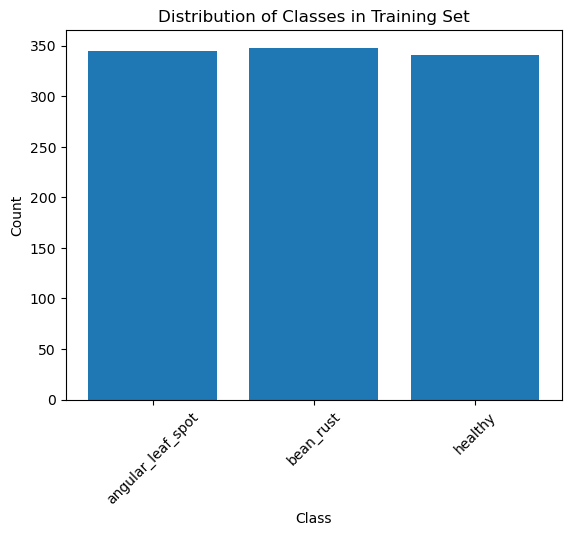

In [4]:
class_names = ['angular_leaf_spot', 'bean_rust', 'healthy']

# Extract all labels from the training set
train_labels = np.array([label.numpy() for _, label in train_ds])

# --- Your code here ---
# Plot a bar chart of class counts
# Hint: use np.unique with return_counts=True, then plt.bar
classes, counts = np.unique(train_labels, return_counts=True)
plt.bar(classes, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Set')
plt.xticks(classes, class_names, rotation=45)
plt.show()

### Sample Images

Let's look at some examples. Can you see visual differences between the classes?

2026-04-17 03:49:56.484640: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


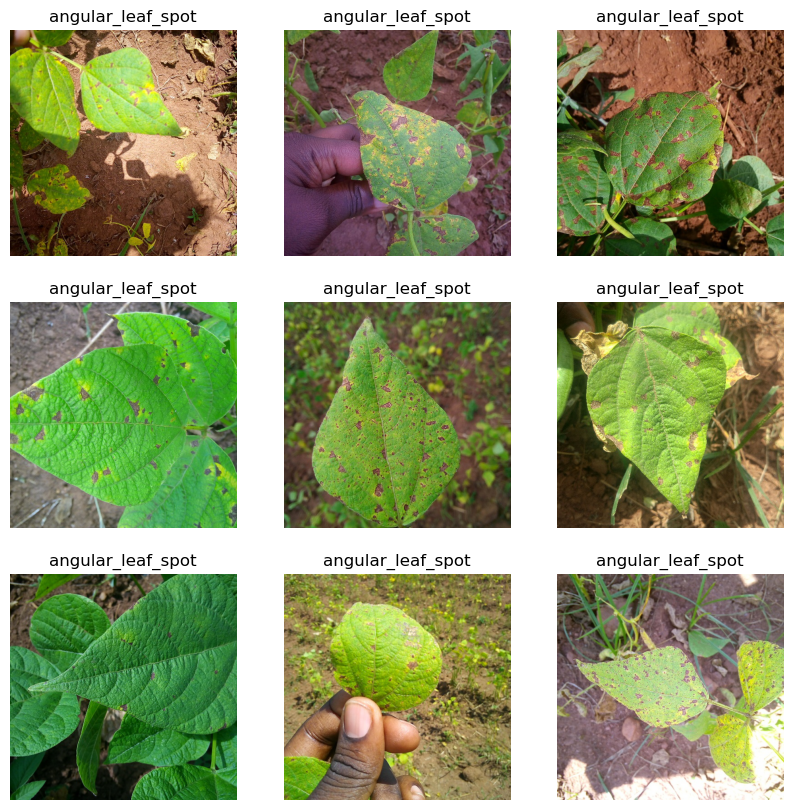

In [5]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label)])
    plt.axis("off")

**Task:** What are the original image dimensions? Write a line of code to print the shape of one image from the training set.

In [6]:
# --- Your code here ---
# Print the shape of the first image in train_ds
print(next(iter(train_ds))[0].shape)

(500, 500, 3)


## Part 1 — CNN from Scratch

We will resize all images to $150 \times 150$ to keep training fast. The Rescaling layer inside the model will normalise pixel values to $[0, 1]$ at training time.

We keep a copy of the original datasets so we can easily try a different size later for the transfer learning part.

In [7]:
IMAGE_SIZE = 150
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

resize_fn = tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)

train150_ds = (
    train_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation150_ds = (
    validation_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test150_ds = (
    test_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### Model Definition

A straightforward CNN: three Conv+Pool blocks, then GlobalAveragePooling2D to collapse the spatial dimensions, one Dense hidden layer, and a 3-unit output.

A few things to note:
- The output layer has **no activation**. We use `from_logits=True` in the loss function, which is numerically more stable than applying softmax and then computing log-loss.
- We are not using BatchNormalization here to keep the model simple. You would typically add it in a production model.
- We are keeping the architecture modest intentionally — you may well see signs of underfitting, which is the motivation for trying transfer learning.

In [8]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)   # no activation -- from_logits=True in loss
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,291 (126.14 KB)

 Trainable params: 32,291 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### Training

We train for 20 epochs. Early stopping could be used here to automatically find a good stopping point, but the focus of today is on comparing scratch vs transfer learning, so we keep it simple.

Watch both `accuracy` and `val_accuracy` as it trains. What do you notice about the gap between them?

In [10]:
history = model.fit(
    train150_ds,
    validation_data=validation150_ds,
    epochs=20
)

Epoch 1/20


2026-04-17 03:49:58.106864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


     33/Unknown 9s 117ms/step - accuracy: 0.5582 - loss: 1.2231

2026-04-17 03:50:07.101215: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:50:07.101234: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_28]]
2026-04-17 03:50:07.101240: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8232877966789356861
2026-04-17 03:50:07.101245: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 4265459423709978939
2026-04-17 03:50:07.101249: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3335196141184248063
2026-04-17 03:50:07.101252: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8524344720048547857
2026-04-17

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.3027 - loss: 1.4212 - val_accuracy: 0.3383 - val_loss: 1.1009
Epoch 2/20
 1/33 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.0000e+00 - loss: 1.0852

...

2026-04-17 03:51:18.594937: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:51:18.594956: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5681569431043289278
2026-04-17 03:51:18.594961: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-04-17 03:51:18.594964: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3892593390490466893
2026-04-17 03:51:18.594968: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 284881600288134605
2026-04-17 03:51:18.594972: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3051907776075961720
2026-04-17 0

32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.0642 - loss: 1.1141

2026-04-17 03:51:22.126138: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:51:22.126155: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8705422169295381002
2026-04-17 03:51:22.126159: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/Cast_1/_3]]
2026-04-17 03:51:22.126176: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 574852008548425739
2026-04-17 03:51:22.126181: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6579303550105174864
2026-04-17 03:51:22.126190: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 54690984161476539

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.3298 - loss: 1.1059 - val_accuracy: 0.3308 - val_loss: 1.0996


2026-04-17 03:51:22.576342: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:51:22.576363: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5681569431043289278
2026-04-17 03:51:22.576367: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2026-04-17 03:51:22.576373: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3892593390490466893
2026-04-17 03:51:22.576377: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 284881600288134605
2026-04-17 03:51:22.576383: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3051907776075961720
2026-04-17 0

### Plotting Training History

**Task:** Plot the training and validation accuracy and loss curves. What do the curves tell you about overfitting or underfitting?

- If training accuracy is much higher than validation accuracy: overfitting
- If both are low and close together: underfitting

Note the final **validation accuracy** — this is the number you will compare against the transfer learning model.

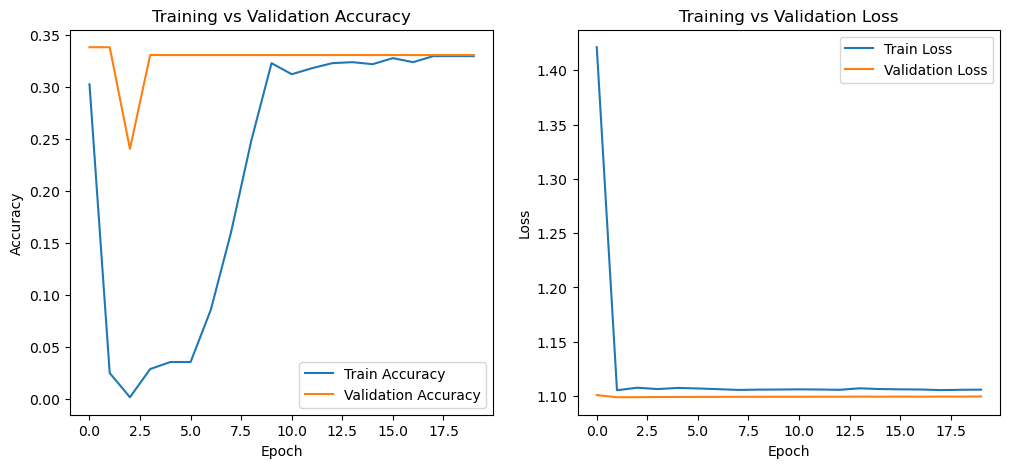

In [11]:
# --- Your code here ---
# Plot training vs validation accuracy
# Plot training vs validation loss
# (two separate plots, or two subplots side by side)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

**Discussion:** If training accuracy is below around 80%, the model is likely underfitting -- a deeper network or more epochs might help. We could also add BatchNormalization or data augmentation. We are going to move on to transfer learning to address this more effectively, but it is worth knowing that improving the scratch model further is a valid path too.

---

## Part 2 — Transfer Learning

Now we will use **Xception** pre-trained on ImageNet as a base model. Xception was trained on millions of images and has already learned to detect edges, textures, and shapes that are useful for almost any image classification task.

The plan:
1. Load Xception with the top (classifier) layers removed
2. Freeze the base model weights
3. Add our own classifier head on top
4. Train only the new head
5. Fine-tune: unfreeze part of the base model and train again at a very low learning rate

Refer to the transfer learning lecture notes and the [Keras guide](https://keras.io/guides/transfer_learning/) for the API.

### Step 1 — Image Size

Xception has a minimum input size. Look it up in the [Keras documentation](https://keras.io/api/applications/xception/) before continuing.

**Task:** Create resized and batched versions of the three datasets for use with Xception. Choose an appropriate image size. Use the same pipeline pattern as above (`.map`, `.batch`, `.prefetch`). Call them `train_xc_ds`, `validation_xc_ds`, `test_xc_ds`.

In [12]:
# --- Your code here ---
# XC_SIZE = ?   # check the Keras docs for Xception minimum input size
# Create train_xc_ds, validation_xc_ds, test_xc_ds
XC_SIZE = 100
resize_xc_fn = tf.keras.layers.Resizing(XC_SIZE, XC_SIZE)

train_xc_ds = (
    train_ds
    .map(lambda x, y: (resize_xc_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation_xc_ds = (
    validation_ds
    .map(lambda x, y: (resize_xc_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_xc_ds = (
    test_ds
    .map(lambda x, y: (resize_xc_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### Step 2 — Load the Base Model

**Task:** Load Xception with:
- `include_top=False` (removes the ImageNet classifier head)
- `weights='imagenet'` (loads pre-trained weights)
- The correct `input_shape` for your chosen image size

Then freeze it. Check the lecture notes for the one-line freeze call.

In [13]:
# --- Your code here ---
# base_model = tf.keras.applications.Xception(...)
# freeze it
# print how many trainable and non-trainable parameters it has
base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(XC_SIZE, XC_SIZE, 3)
)
base_model.trainable = False
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(p) for p in base_model.trainable_weights])}")
print(f"Non-trainable parameters: {sum([tf.keras.backend.count_params(p) for p in base_model.non_trainable_weights])}")


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Trainable parameters: 0
Non-trainable parameters: 20861480


### Step 3 — Preprocessing

Xception expects inputs normalised in a specific way -- **not** simply divided by 255. It has its own preprocessing function.

**Task:** Find the correct preprocessing function for Xception in the Keras documentation and apply it in the model below.

### Step 4 — Build the New Model

Using the Functional API (required here because we are grafting onto an existing model), build a model that:
1. Takes an input of your chosen image size
2. Applies the Xception preprocessing function
3. Passes through the frozen base model (`training=False` — check your notes for why this matters with BatchNormalization)
4. Applies `GlobalAveragePooling2D`
5. Adds a `Dense` output layer with 3 units and no activation

Then compile and call `model_tl.summary()`.

In [14]:
# Data augmentation pipeline — active during training, no-op at inference
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [15]:
# --- Your code here ---
# Build model_tl using the Functional API
# Compile with Adam, SparseCategoricalCrossentropy(from_logits=True), accuracy
inputs = tf.keras.Input(shape=(XC_SIZE, XC_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.xception.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes)(x)
model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model_tl.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 3, 3, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,867,627 (79.60 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

**Look at the summary.** How many trainable parameters does your model have now compared to the scratch CNN? The base model weights are frozen so they are listed as non-trainable.

### Step 5 — Train the Head

Train for 10 epochs. We are only training the new layers on top -- the base model weights are frozen. Early stopping could be used here to find the optimal number of epochs automatically, but we keep it simple for today.

Watch the validation accuracy. How does it compare to the scratch CNN?

In [16]:
# --- Your code here ---
# history_tl = model_tl.fit(...)
history_tl = model_tl.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)


Epoch 1/10
     33/Unknown 10s 134ms/step - accuracy: 0.4649 - loss: 1.7450

2026-04-17 03:51:37.019805: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:51:37.019834: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13570963719209110
2026-04-17 03:51:37.019840: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 9025635141489340786
2026-04-17 03:51:37.019856: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/functional_2_1/sequential_1_1/random_zoom_1/stateless_random_uniform/StatelessRandomGetKeyCounter/_88]]
2026-04-17 03:51:37.019870: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 4982313896607344854
2026-04-17 03:51:37.019882: I tensorflow/core/framework

33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - accuracy: 0.2737 - loss: 2.4981 - val_accuracy: 0.4060 - val_loss: 1.5924
Epoch 2/10


2026-04-17 03:51:40.549035: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:51:40.549053: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13743410906116442092
2026-04-17 03:51:40.549055: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/BitwiseAnd/_12]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0687 - loss: 2.3518

...

2026-04-17 03:52:14.032203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:52:14.032222: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13743410906116442092
2026-04-17 03:52:14.032243: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/BitwiseAnd/_12]]


32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4831 - loss: 1.0805

2026-04-17 03:52:17.515064: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:52:17.515091: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 6551929119181109008
2026-04-17 03:52:17.515095: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_22]]
2026-04-17 03:52:17.515107: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13570963719209110
2026-04-17 03:52:17.515113: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 2354590618285855542
2026-04-17 03:52:17.515115: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 9025635141489340786
2026-04-17 0

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.5706 - loss: 0.9488 - val_accuracy: 0.6316 - val_loss: 0.8678


2026-04-17 03:52:18.062416: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:52:18.062435: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 13743410906116442092
2026-04-17 03:52:18.062444: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/BitwiseAnd/_12]]


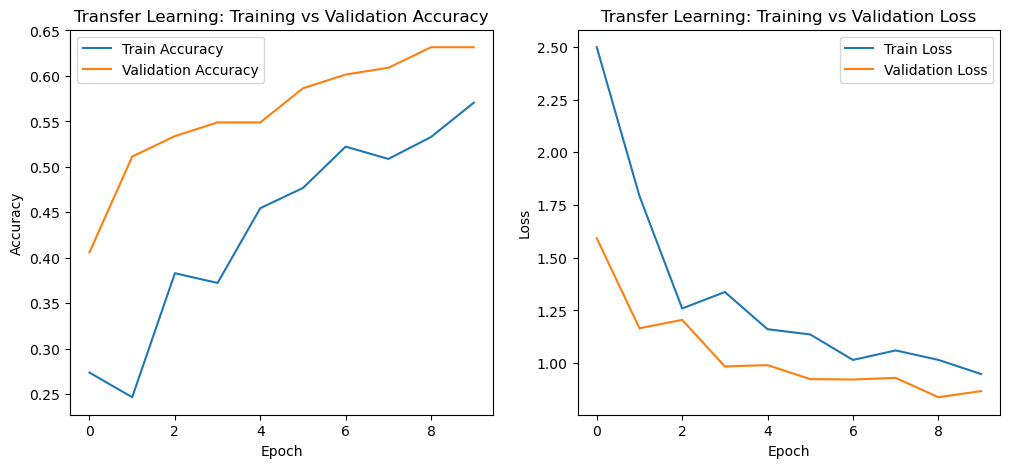

In [17]:
# --- Your code here ---
# Plot training and validation accuracy/loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Learning: Training vs Validation Loss')
plt.legend()
plt.show()


### Step 6 — Add a Dense Hidden Layer (Optional Extension)

The classifier head above goes straight from GlobalAveragePooling2D to the output. Try adding a Dense hidden layer (e.g. 256 units, ReLU activation) between the pooling and the output layer. Does it improve validation accuracy?

Rebuild, recompile, and retrain. Record the validation accuracy for each version.

In [18]:
# --- Optional: Your code here ---
# Build model_tl_v2 with an extra Dense layer in the head
inputs = tf.keras.Input(shape=(XC_SIZE, XC_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.xception.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes)(x)
model_tl_v2 = tf.keras.Model(inputs, outputs)

model_tl_v2.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_tl_v2 = model_tl_v2.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)

print(f"\nmodel_tl_v2 final val accuracy: {history_tl_v2.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
     33/Unknown 8s 136ms/step - accuracy: 0.6176 - loss: 6.5602

2026-04-17 03:52:26.535224: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:52:26.535247: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7733062723198427340
2026-04-17 03:52:26.535252: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10907595306167877998
2026-04-17 03:52:26.535264: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 9603459310133355150
2026-04-17 03:52:26.535270: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3119514621133141190
2026-04-17 03:52:26.535275: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8459633266146637174
2026-04-17 03:52:26.535277: W tensorflow/core/framework/local_rendezvo

33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.3201 - loss: 12.9008 - val_accuracy: 0.3383 - val_loss: 7.5918
Epoch 2/10


2026-04-17 03:52:30.248311: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:52:30.248330: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-04-17 03:52:30.248338: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 3674725997917895035
2026-04-17 03:52:30.248343: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 1683703108270607625
2026-04-17 03:52:30.248349: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 12696539248397140604
2026-04-17 03:52:30.248353: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 17436795906706109352
2026-04-1

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.0528 - loss: 7.8081

...

2026-04-17 03:53:02.738392: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:53:02.738411: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7733062723198427340
2026-04-17 03:53:02.738418: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10907595306167877998
2026-04-17 03:53:02.738423: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 9603459310133355150
2026-04-17 03:53:02.738468: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 4723968894058914644
2026-04-17 03:53:02.738475: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/adam/Ad

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3230 - loss: 2.8869 - val_accuracy: 0.5414 - val_loss: 2.0407
Epoch 10/10


2026-04-17 03:53:03.302856: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-04-17 03:53:03.302877: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 1683703108270607625
2026-04-17 03:53:03.302902: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


28/33 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1474 - loss: 3.6504

KeyboardInterrupt: 

### Step 7 — Fine-Tuning

Now unfreeze the top layers of the base model and train the whole model at a **very low learning rate**. This makes small adjustments to the pre-trained weights to better fit our dataset.

**Task:**
1. Set `base_model.trainable = True`
2. Freeze everything up to layer 100 (keep the early feature-detector layers frozen)
3. Recompile with a learning rate of `1e-5`
4. Train for 10 more epochs

Check your lecture notes for the fine-tuning code pattern. Make sure you recompile after changing which layers are trainable -- Keras requires this.

In [ ]:
# --- Your code here ---
# Unfreeze base_model
# Freeze layers[:100]
# Recompile with learning_rate=1e-5
# Fit for 10 more epochs
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.7495 - loss: 0.6881 - val_accuracy: 0.8045 - val_loss: 0.4346
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8607 - loss: 0.4968 - val_accuracy: 0.8195 - val_loss: 0.4641
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9072 - loss: 0.3903 - val_accuracy: 0.8271 - val_loss: 0.4296
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9275 - loss: 0.3151 - val_accuracy: 0.8571 - val_loss: 0.3911
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9478 - loss: 0.2567 - val_accuracy: 0.8647 - val_loss: 0.3675
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9652 - loss: 0.2099 - val_accuracy: 0.8797 - val_loss: 0.3518
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9768 - loss: 0.1721 - val_accuracy: 0.8722 - val_loss: 0.3406
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9836 - loss: 0.1416 - val_accuracy: 0.8797 -

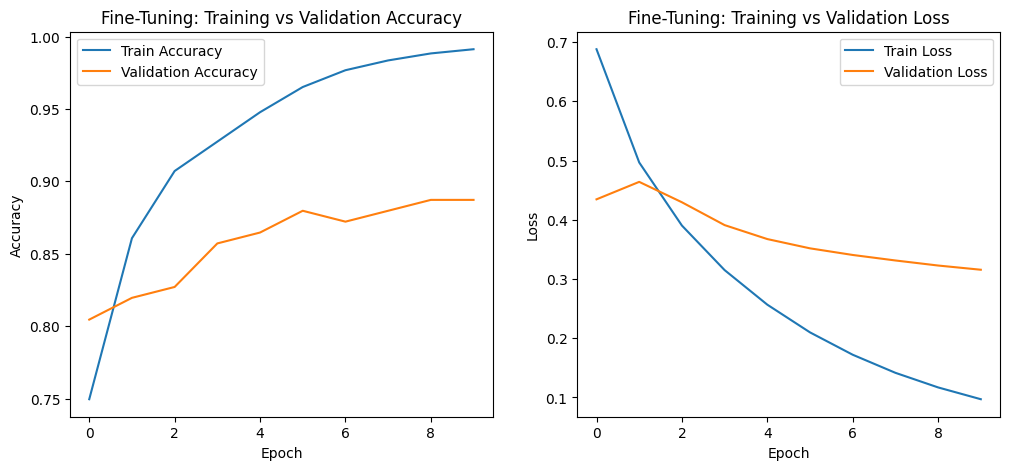

In [ ]:
# --- Your code here ---
# Plot the fine-tuning training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-Tuning: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning: Training vs Validation Loss')
plt.legend()
plt.show()


### Step 8 — Compare Models on the Validation Set

**Task:** Use `model.evaluate()` on `validation_xc_ds` (not the test set) for each model variant you have trained. Record the validation accuracy for:
- Scratch CNN
- Transfer learning (head only)
- Transfer learning (after fine-tuning)

Which is best? **This** is how you choose your final model -- using validation scores, not the test set.

In [ ]:
# --- Your code here ---
# Evaluate each model on the validation set and print the results
# You will need to evaluate the scratch CNN on validation150_ds
# and the transfer learning model on validation_xc_ds
scratch_loss, scratch_acc = model.evaluate(validation150_ds, verbose=0)
tl_head_acc = history_tl.history['val_accuracy'][-1]
tl_ft_loss, tl_ft_acc = model_tl.evaluate(validation_xc_ds, verbose=0)

print(f"Scratch CNN validation accuracy:              {scratch_acc:.4f}")
print(f"Transfer learning (head only) val accuracy:   {tl_head_acc:.4f}")
print(f"Transfer learning (fine-tuned) val accuracy:  {tl_ft_acc:.4f}")

Scratch CNN validation accuracy:              0.7744
Transfer learning (head only) val accuracy:   0.8346
Transfer learning (fine-tuned) val accuracy:  0.8872


### Step 9 — Final Evaluation on the Test Set

Now that you have chosen your best model based on validation performance, evaluate it **once** on the test set. This is your honest estimate of how well the model will perform on unseen data.

Do not go back and change your model after seeing the test score.

In [ ]:
# --- Your code here ---
# Evaluate your chosen best model on the appropriate test dataset
test_loss, test_acc = model_tl.evaluate(test_xc_ds, verbose=0)
print(f"Final test accuracy (fine-tuned transfer learning): {test_acc:.4f}")

Final test accuracy (fine-tuned transfer learning): 0.8750
